In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ======================================
# 2. LOAD DATA
# ======================================
df = pd.read_csv("exchange_rate.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

series = df['Ex_rate']

# ======================================
# 3. EDA
# ======================================
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Exchange Rate Time Series")
plt.show()

# Rolling Mean
series.rolling(window=30).mean().plot(title="Rolling Mean")
plt.show()

# ======================================
# 4. CHECK STATIONARITY (ADF TEST)
# ======================================
result = adfuller(series.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# ======================================
# 5. DIFFERENCING
# ======================================
series_diff = series.diff().dropna()

# ACF & PACF
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

# ======================================
# 6. TRAIN-TEST SPLIT
# ======================================
train_size = int(len(series)*0.8)
train, test = series[:train_size], series[train_size:]

# ======================================
# 7. ARIMA MODEL
# ======================================
arima = ARIMA(train, order=(2,1,2))
arima_fit = arima.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

# Residuals
residuals = arima_fit.resid
plt.plot(residuals)
plt.title("Residuals")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# ======================================
# 8. EXPONENTIAL SMOOTHING
# ======================================
exp_model = ExponentialSmoothing(train, trend='add')
exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(len(test))

# ======================================
# 9. EVALUATION
# ======================================
def evaluate(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

arima_metrics = evaluate(test, arima_forecast)
exp_metrics = evaluate(test, exp_forecast)

print("ARIMA -> MAE, RMSE, MAPE:", arima_metrics)
print("EXP SMOOTHING -> MAE, RMSE, MAPE:", exp_metrics)

# ======================================
# 10. VISUALIZATION
# ======================================
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, exp_forecast, label='Exp Smoothing')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [1]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# ======================================
# 2. LOAD DATA
# ======================================
df = pd.read_csv("exchange_rate.csv")
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")
df.set_index('date', inplace=True)

series = df['Ex_rate']

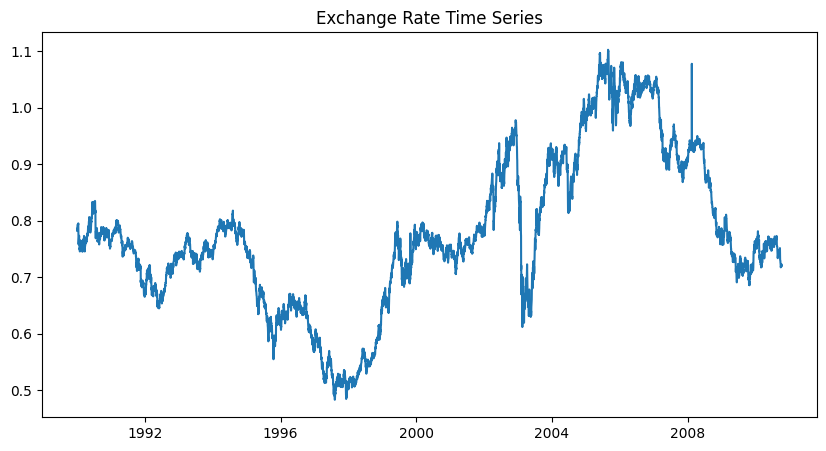

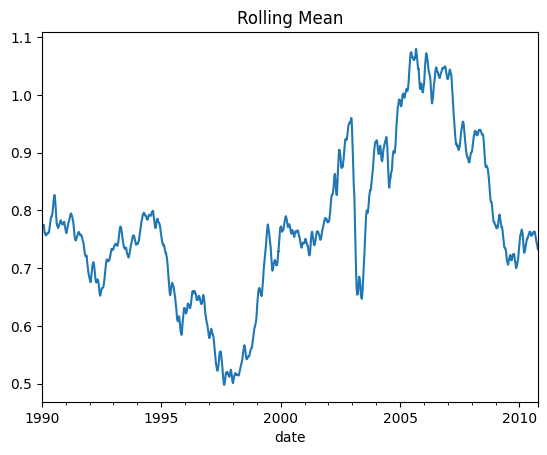

In [4]:
# ======================================
# 3. EDA
# ======================================
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Exchange Rate Time Series")
plt.show()

# Rolling Mean
series.rolling(window=30).mean().plot(title="Rolling Mean")
plt.show()

In [5]:
# ======================================
# 4. CHECK STATIONARITY (ADF TEST)
# ======================================
result = adfuller(series.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


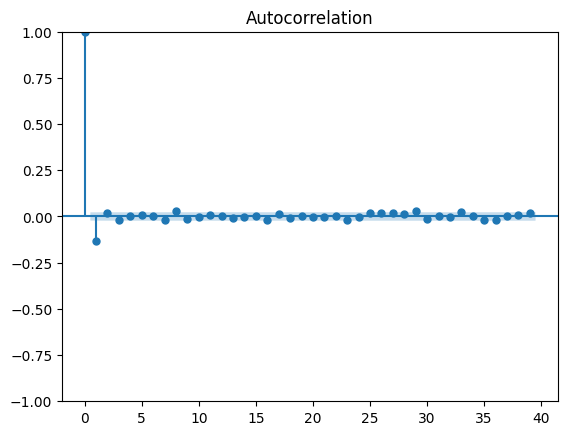

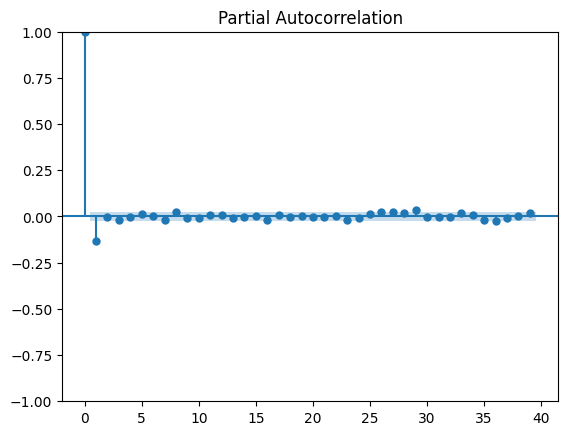

In [6]:
# ======================================
# 5. DIFFERENCING
# ======================================
series_diff = series.diff().dropna()

# ACF & PACF
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

In [7]:
# ======================================
# 6. TRAIN-TEST SPLIT
# ======================================
train_size = int(len(series)*0.8)
train, test = series[:train_size], series[train_size:]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


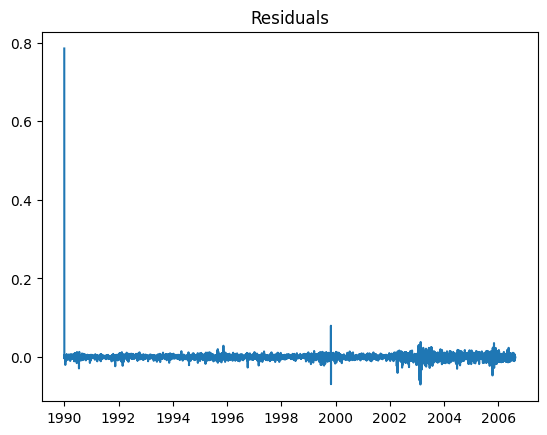

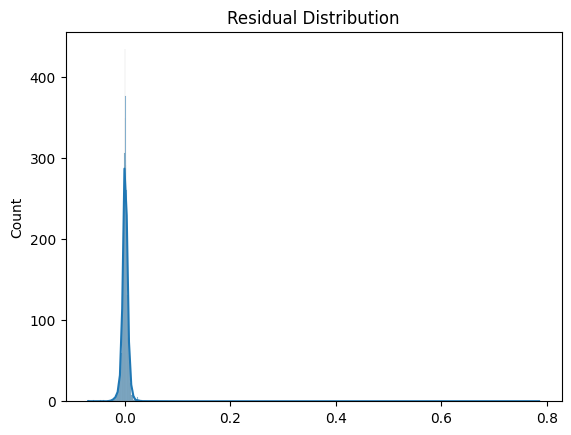

In [8]:
# ======================================
# 7. ARIMA MODEL
# ======================================
arima = ARIMA(train, order=(2,1,2))
arima_fit = arima.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

# Residuals
residuals = arima_fit.resid
plt.plot(residuals)
plt.title("Residuals")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [9]:
# ======================================
# 8. EXPONENTIAL SMOOTHING
# ======================================
exp_model = ExponentialSmoothing(train, trend='add')
exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [10]:
# ======================================
# 9. EVALUATION
# ======================================
def evaluate(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

arima_metrics = evaluate(test, arima_forecast)
exp_metrics = evaluate(test, exp_forecast)

print("ARIMA -> MAE, RMSE, MAPE:", arima_metrics)
print("EXP SMOOTHING -> MAE, RMSE, MAPE:", exp_metrics)

ARIMA -> MAE, RMSE, MAPE: (0.17769929903408996, np.float64(0.20542502366801688), np.float64(22.796642124003224))
EXP SMOOTHING -> MAE, RMSE, MAPE: (0.20659619114093827, np.float64(0.23910443161792286), np.float64(26.50866379878783))


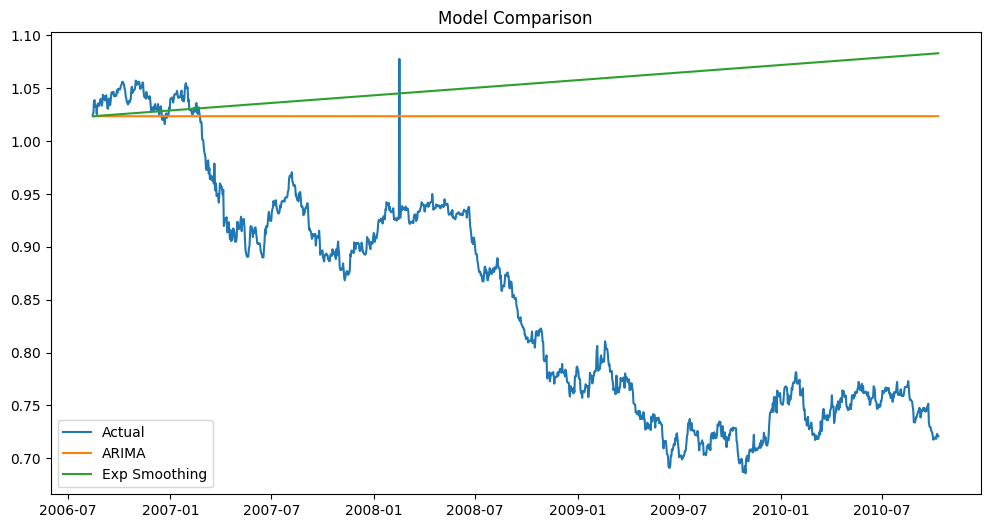

In [11]:
# ======================================
# 10. VISUALIZATION
# ======================================
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, exp_forecast, label='Exp Smoothing')
plt.legend()
plt.title("Model Comparison")
plt.show()